# Model 1 - SVM with PCA
Model 1 will be used as a baseline model since it will be the simplest model and will implement a support vector machine (SVM)
using principal component analysis (PCA) as the dimensionality reduction technique.

Authors: Christian Quintero, Lilyanna Yang

Date: 06/12/2026

## To Run
See the README file for instructions on how to setup your venv and select it as your python kernel


In [308]:
"""
this cell contains all the imports
and constants used
"""
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
PrecisionRecallDisplay)

"""
constants

SEED - the seed value for random operations and reproducibility

TEST_SIZE - the proportion of the dataset to include in the test split. 
    Ex) .25 means 25% of the data will be used for testing and 75% for training

VARIANCE - the amount of variance to retain when performing PCA.
    Ex) .95 means we want to retain 95% of the variance in the data
"""
SEED = 0
TEST_SIZE = 0.25
VARIANCE = .95

In [309]:
"""
this cell reads the data into a dataframe and ensures there
are no missing values
"""

file = '../data/spoofing-merged-gps-only.csv'
# file = file.upload()  # if using google colab, upload your file using this line
data = pd.read_csv(file)

# a quick sanity check to ensure there are no nans in the data
nan_count = data.isnull().sum().sum()
assert nan_count == 0, "NaNs were found in the data"

data

,timestamp,q[0],q[1],q[2],q[3],delta_q_reset[0],delta_q_reset[1],delta_q_reset[2],delta_q_reset[3],quat_reset_counter,...,v_z_valid,xy_reset_counter,z_reset_counter,vxy_reset_counter,vz_reset_counter,heading_reset_counter,xy_global,z_global,dist_bottom_valid,label
0,258725029,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,benign
1,258842609,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,benign
2,258847608,-0.325207,0.010554,-0.006518,0.945561,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,benign
3,258852607,-0.325204,0.010556,-0.006517,0.945562,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,benign
4,258902598,-0.325214,0.010552,-0.006501,0.945559,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3617,394999457,-0.174310,0.114898,-0.977597,-0.026797,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,malicious
3618,395054416,-0.174412,0.114565,-0.977624,-0.026601,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,malicious
3619,395099400,-0.174498,0.114292,-0.977644,-0.026460,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,malicious
3620,395144392,-0.174543,0.114137,-0.977656,-0.026383,0.999995,-4.610000e-10,1.580000e-09,0.003237,3,...,1,2,0,2,1,3,1,1,1.0,malicious


In [310]:
"""
this cell will clean the data by removing columns that
are not useful
"""

# this loop identifies columns that have constant values across all rows
# and are therefore not useful for distinguishing between classes
columns_to_drop = []
for col in data.columns:
    if data[col].nunique() == 1:
        columns_to_drop.append(col)

# remove timing columns
timing = ['timestamp', 'time_utc_usec', 'timestamp_time_relative']
columns_to_drop += timing

# drop the cols and list which ones were dropped
data.drop(columns=columns_to_drop, inplace=True)
print(f'Removed {len(columns_to_drop)} columns')
for col in columns_to_drop:
    print(f'Dropped column: {col}')

# convert the labels to 0 and 1
data['label'] = data['label'].replace('benign', 0)
data['label'] = data['label'].replace('malicious', 1)

# cast to floats
data = data.astype(float, errors='raise')

# ensure all values are numeric
values = data.to_numpy().flatten()
for v in values:
    assert isinstance(v, float), f"Non-numeric value found: {v}"

# send the cleaned data to a new csv file to examine what the cleaned data looks like
data.to_csv('../data/model1-cleaned.csv', index=False)
data

Removed 36 columns
Dropped column: delta_q_reset[0]
Dropped column: delta_q_reset[1]
Dropped column: delta_q_reset[2]
Dropped column: delta_q_reset[3]
Dropped column: quat_reset_counter
Dropped column: delta_alt
Dropped column: lat_lon_reset_counter
Dropped column: alt_reset_counter
Dropped column: dead_reckoning
Dropped column: time_utc_usec
Dropped column: timestamp_time_relative
Dropped column: heading_offset
Dropped column: fix_type
Dropped column: vel_ned_valid
Dropped column: ref_lat
Dropped column: ref_lon
Dropped column: delta_xy[0]
Dropped column: delta_xy[1]
Dropped column: delta_z
Dropped column: delta_vxy[0]
Dropped column: delta_vxy[1]
Dropped column: delta_vz
Dropped column: delta_heading
Dropped column: ref_alt
Dropped column: z_valid
Dropped column: v_z_valid
Dropped column: xy_reset_counter
Dropped column: z_reset_counter
Dropped column: vxy_reset_counter
Dropped column: vz_reset_counter
Dropped column: heading_reset_counter
Dropped column: xy_global
Dropped column: z_

,q[0],q[1],q[2],q[3],lat_x,lon_x,alt_x,alt_ellipsoid_x,eph_x,epv_x,...,heading_y,dist_bottom,eph,epv,evh,evv,xy_valid,v_xy_valid,dist_bottom_valid,label
0,-0.325207,0.010554,-0.006518,0.945561,36.204812,138.252916,51.336754,86.740776,2.718645,3.927061,...,-2.478927,0.100087,0.506743,0.376203,0.146638,0.080836,1.000000,1.000000,1.0,0.0
1,-0.325207,0.010554,-0.006518,0.945561,36.204812,138.252916,51.336754,86.740776,2.718645,3.927061,...,-2.478927,0.100087,0.506743,0.376203,0.146638,0.080836,1.000000,1.000000,1.0,0.0
2,-0.325207,0.010554,-0.006518,0.945561,36.204812,138.252916,51.336619,86.740643,2.718710,3.927086,...,-2.478930,0.100299,0.507089,0.376460,0.146858,0.080883,1.000000,1.000000,1.0,0.0
3,-0.325204,0.010556,-0.006517,0.945562,36.204812,138.252916,51.336483,86.740510,2.718774,3.927111,...,-2.478933,0.100511,0.507435,0.376718,0.147079,0.080930,1.000000,1.000000,1.0,0.0
4,-0.325214,0.010552,-0.006501,0.945559,36.204812,138.252916,51.335785,86.738014,2.718747,3.927090,...,-2.479119,0.100341,0.509815,0.376991,0.148562,0.081118,1.000000,1.000000,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3617,-0.174310,0.114898,-0.977597,-0.026797,36.204926,138.252910,51.857122,85.227116,3.073185,3.945737,...,-2.910159,0.138471,1.529067,0.537552,0.345229,0.161112,0.666667,0.666667,1.0,1.0
3618,-0.174412,0.114565,-0.977624,-0.026601,36.204926,138.252910,51.857193,85.224700,3.073585,3.945710,...,-2.910584,0.138991,1.520750,0.536979,0.341910,0.160781,1.000000,1.000000,1.0,1.0
3619,-0.174498,0.114292,-0.977644,-0.026460,36.204926,138.252910,51.857193,85.224700,3.073585,3.945710,...,-2.911109,0.136282,1.529566,0.539249,0.344074,0.161228,1.000000,1.000000,1.0,1.0
3620,-0.174543,0.114137,-0.977656,-0.026383,36.204926,138.252910,51.857193,85.224700,3.073585,3.945710,...,-2.911635,0.133573,1.538381,0.541518,0.346238,0.161674,1.000000,1.000000,1.0,1.0


In [311]:
"""
this cell splits the data into training and testing sets
"""

# extract the labels and then drop them from the data
y = data['label']
X = data.drop(columns = ['label'])

# assert the labels were dropped and converted successfully
assert 'label' not in X.columns, "The labels were not dropped successfully"
assert y.isin([0, 1]).all(), "The labels were not converted to 0 and 1 successfully"

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = TEST_SIZE,
    shuffle = True,
    random_state = SEED,
    stratify = y
)

# convert the training and testing sets to dataframes
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

# another sanity check to ensure labels are not in the training and testing sets
assert 'label' not in X_train.columns, "The labels were not dropped successfully from the training set"
assert 'label' not in X_test.columns, "The labels were not dropped successfully from the testing set"

print(f'Training set shape X: {X_train.shape}, Y: {y_train.shape}')
print(f'Testing set shape X: {X_test.shape}, Y: {y_test.shape}')

print(f'Malicious samples in training set: {y_train.sum()}')
print(f'Malicious samples in testing set: {y_test.sum()}')

Training set shape X: (2716, 49), Y: (2716,)
Testing set shape X: (906, 49), Y: (906,)
Malicious samples in training set: 373.0
Malicious samples in testing set: 125.0


In [312]:
"""
this cell will scale the data
"""

# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

True Negatives:  781
False Negatives: 0
True Positives:  125
False Positives: 0
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


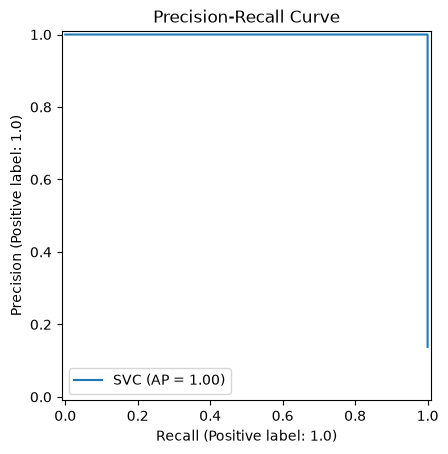

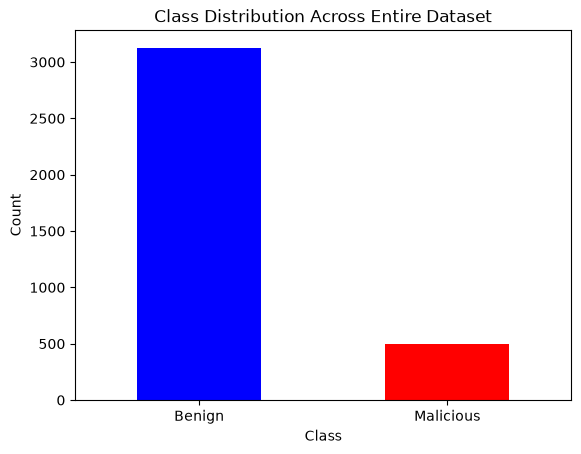

In [313]:
"""
this cell trains an SVM on the training data and evaluates it on the testing data
"""

# train an SVM on the training data
svc = SVC(kernel='rbf', class_weight='balanced', random_state=SEED)
svc.fit(X_train_scaled, y_train)

# make predictions on the testing data
y_pred = svc.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
print(f'True Negatives:  {cm[0, 0]}')
print(f'False Negatives: {cm[1, 0]}')
print(f'True Positives:  {cm[1, 1]}')
print(f'False Positives: {cm[0, 1]}')

acc = round(accuracy_score(y_test, y_pred), 2)
prec = round(precision_score(y_test, y_pred), 2)
rec = round(recall_score(y_test, y_pred), 2)
f1 = round(f1_score(y_test, y_pred), 2)

print(f'Accuracy: {acc}')
print(f'Precision: {prec}')
print(f'Recall: {rec}')
print(f'F1 Score: {f1}')

PrecisionRecallDisplay.from_estimator(svc, X_test_scaled, y_test)
plt.title('Precision-Recall Curve')
plt.show()

y.value_counts().plot(kind='bar', color=['blue', 'red'])
plt.xticks([0, 1], ['Benign', 'Malicious'], rotation=0)
plt.title('Class Distribution Across Entire Dataset')
plt.ylabel('Count')
plt.xlabel('Class')
plt.show()